In [1]:
import pandas as pd

df_base = pd.read_csv("CPI_Historic_Values_Zindi.csv")
df_feb = pd.read_csv("CPI_Historic_Values_Zindi_Feb_23.csv")
df_apr = pd.read_csv("CPI_Historic_Values_Zindi_Apr_23.csv")
df_may = pd.read_csv("CPI_Historic_Values_Zindi_May_23.csv")

In [2]:
df_all = pd.concat([df_base, df_feb, df_apr, df_may])

In [3]:
print(df_all.columns)

Index(['Month', 'Category', 'Value', 'Percentage Change (From Prior Month)',
       'Unnamed: 4'],
      dtype='object')


In [4]:
df_all = df_all.drop_duplicates(subset=['Month'], keep='last')

In [5]:
df_all['Month'] = pd.to_datetime(df_all['Month'])
df_all = df_all.sort_values('Month')

C:\Users\R8885477\AppData\Local\Temp\ipykernel_10140\3400372755.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_all['Month'] = pd.to_datetime(df_all['Month'])


In [6]:
df_all = df_all.reset_index(drop=True)

In [7]:
df_all.tail()
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 5 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Month                                 17 non-null     datetime64[ns]
 1   Category                              17 non-null     object        
 2   Value                                 17 non-null     float64       
 3   Percentage Change (From Prior Month)  17 non-null     float64       
 4   Unnamed: 4                            0 non-null      float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 812.0+ bytes


In [8]:
df_pivot = df_all.pivot(index='Month', columns='Category', values='Value')

In [9]:
df_pivot = df_pivot.reset_index()

In [10]:
df_pivot.head()

Category,Month,Miscellaneous goods and services
0,2022-01-31,100.6
1,2022-02-28,101.5
2,2022-03-31,101.9
3,2022-04-30,102.8
4,2022-05-31,102.9


In [11]:
df_all['Category'].unique()

array(['Miscellaneous goods and services'], dtype=object)

In [12]:
print(df_base.shape)
print(df_feb.shape)
print(df_apr.shape)
print(df_may.shape)

(169, 5)
(182, 5)
(208, 4)
(221, 4)


In [13]:
df_base = pd.read_csv("CPI_Historic_Values_Zindi.csv", encoding='latin1')
df_feb = pd.read_csv("CPI_Historic_Values_Zindi_Feb_23.csv", encoding='latin1')
df_apr = pd.read_csv("CPI_Historic_Values_Zindi_Apr_23.csv", encoding='latin1')
df_may = pd.read_csv("CPI_Historic_Values_Zindi_May_23.csv", encoding='latin1')

In [14]:
df_base.head()
df_base['Category'].unique()

array(['Headline_CPI', 'Food and non-alcoholic beverages',
       'Alcoholic beverages and tobacco', 'Clothing and footwear',
       'Housing and utilities', 'Household contents and services',
       'Health', 'Transport', 'Communication', 'Recreation and culture',
       'Education', 'Restaurants and hotels ',
       'Miscellaneous goods and services'], dtype=object)

In [15]:
df_pivot = df_all.pivot(index='Month', columns='Category', values='Value')

In [16]:
df_pivot.shape

(17, 1)

In [17]:
df_base.head()

,Month,Category,Value,Percentage Change (From Prior Month),Unnamed: 4
0,31-01-2023,Headline_CPI,107.1,-0.1,NaN
1,31-01-2023,Food and non-alcoholic beverages,114.4,1.8,NaN
2,31-01-2023,Alcoholic beverages and tobacco,106.5,0.3,NaN
3,31-01-2023,Clothing and footwear,102.9,0.1,NaN
4,31-01-2023,Housing and utilities,104.1,0.0,NaN


In [18]:
df_all['Category'] = df_all['Category'].str.strip()
df_all['Category'] = df_all['Category'].str.replace('_', ' ')

In [19]:
df_all['Category'] = df_all['Category'].replace({
    'Headline CPI': 'Headline CPI',
    'Headline_CPI': 'Headline CPI'
})

In [20]:
df_all['Category'].unique()

array(['Miscellaneous goods and services'], dtype=object)

In [21]:
df_pivot = df_all.pivot(index='Month', columns='Category', values='Value')
df_pivot = df_pivot.reset_index()

In [22]:
df_all = pd.concat([df_base, df_feb, df_apr, df_may], ignore_index=True)

In [23]:
df_all['Month'].nunique()

17

In [24]:
df_all = pd.concat(
    [df_base, df_feb, df_apr, df_may],
    ignore_index=True
)


In [25]:
df_all['Category'] = (
    df_all['Category']
    .str.strip()
    .str.replace('_', ' ', regex=False)
)

df_all['Category'] = df_all['Category'].replace({
    'Headline CPI': 'Headline CPI'
})

In [26]:
print(df_all['Category'].value_counts())
print(df_all['Month'].nunique())

Category
Headline CPI                        60
Food and non-alcoholic beverages    60
Alcoholic beverages and tobacco     60
Clothing and footwear               60
Housing and utilities               60
Household contents and services     60
Health                              60
Transport                           60
Communication                       60
Recreation and culture              60
Education                           60
Restaurants and hotels              60
Miscellaneous goods and services    60
Name: count, dtype: int64
17


In [27]:
df_all.groupby(['Month', 'Category']).size().sort_values(ascending=False).head(10)

Month       Category                        
28-02-2022  Alcoholic beverages and tobacco     4
31-07-2022  Education                           4
31-03-2022  Household contents and services     4
            Housing and utilities               4
            Miscellaneous goods and services    4
            Recreation and culture              4
            Restaurants and hotels              4
            Transport                           4
31-05-2022  Alcoholic beverages and tobacco     4
            Clothing and footwear               4
dtype: int64

In [28]:
df_pivot = df_all.pivot_table(
    index='Month',
    columns='Category',
    values='Value',
    aggfunc='last'   # or 'mean'
).reset_index()


In [29]:
df_all = df_all.drop_duplicates(subset=['Month', 'Category'])

In [30]:
df_all = (
    df_all
    .groupby(['Month', 'Category'], as_index=False)
    .agg({'Value': 'last'})
)

df_pivot = df_all.pivot(
    index='Month',
    columns='Category',
    values='Value'
).reset_index()


In [31]:
print(df_pivot.shape)
print(df_pivot.head())


(17, 14)
Category       Month  Alcoholic beverages and tobacco  Clothing and footwear  \
0         28-02-2022                            100.6                  100.3   
1         28-02-2023                            106.9                  103.5   
2         30-04-2022                            103.6                  100.7   
3         30-04-2023                            110.2                  103.7   
4         30-06-2022                            104.5                  101.3   

Category  Communication  Education  Food and non-alcoholic beverages  \
0                  99.7      100.0                             101.8   
1                  99.8      104.4                             115.6   
2                  99.6      104.4                             103.1   
3                  99.8      110.4                             117.4   
4                 100.3      104.4                             106.6   

Category  Headline CPI  Health  Household contents and services  \
0         

In [32]:
# Ensure proper types
df_all['Month'] = pd.to_datetime(df_all['Month'], dayfirst=True)

# Normalize category text
df_all['Category'] = (
    df_all['Category']
    .str.strip()
    .str.replace('_', ' ', regex=False)
)

# Pivot safely
df_pivot = df_all.pivot_table(
    index='Month',
    columns='Category',
    values='Value',
    aggfunc='last'
).reset_index()

In [33]:
df_pivot = df_pivot.sort_values('Month')
df_pivot = df_pivot.set_index('Month')

In [34]:
df_lag1 = df_pivot.shift(1)
df_lag1.columns = [f"{c}_lag1" for c in df_lag1.columns]

df_features = pd.concat([df_pivot, df_lag1], axis=1)
df_features = df_features.dropna()

In [35]:
df_features.head()


,Alcoholic beverages and tobacco,Clothing and footwear,Communication,Education,Food and non-alcoholic beverages,Headline CPI,Health,Household contents and services,Housing and utilities,Miscellaneous goods and services,...,Education_lag1,Food and non-alcoholic beverages_lag1,Headline CPI_lag1,Health_lag1,Household contents and services_lag1,Housing and utilities_lag1,Miscellaneous goods and services_lag1,Recreation and culture_lag1,Restaurants and hotels_lag1,Transport_lag1
Month,,,,,,,,,,,,,,,,,,,,,
2022-02-28,100.6,100.3,99.7,100.0,101.8,100.8,103.2,100.4,100.1,101.5,...,100.0,100.9,100.2,100.1,100.4,100.0,100.6,100.2,101.2,98.9
2022-03-31,102.8,100.5,99.7,104.4,102.4,101.8,103.7,100.8,100.5,101.9,...,100.0,101.8,100.8,103.2,100.4,100.1,101.5,100.3,101.9,100.6
2022-04-30,103.6,100.7,99.6,104.4,103.1,102.4,104.0,101.1,100.5,102.8,...,104.4,102.4,101.8,103.7,100.8,100.5,101.9,100.4,103.0,103.7
2022-05-31,104.4,100.9,99.9,104.4,105.3,103.1,104.3,101.8,100.6,102.9,...,104.4,103.1,102.4,104.0,101.1,100.5,102.8,100.7,103.3,105.1
2022-06-30,104.5,101.3,100.3,104.4,106.6,104.2,104.6,103.0,101.2,103.0,...,104.4,105.3,103.1,104.3,101.8,100.6,102.9,101.0,103.8,105.9


In [36]:
df_features.shape

(16, 26)

In [37]:
df_features.columns


Index(['Alcoholic beverages and tobacco', 'Clothing and footwear',
       'Communication', 'Education', 'Food and non-alcoholic beverages',
       'Headline CPI', 'Health', 'Household contents and services',
       'Housing and utilities', 'Miscellaneous goods and services',
       'Recreation and culture', 'Restaurants and hotels', 'Transport',
       'Alcoholic beverages and tobacco_lag1', 'Clothing and footwear_lag1',
       'Communication_lag1', 'Education_lag1',
       'Food and non-alcoholic beverages_lag1', 'Headline CPI_lag1',
       'Health_lag1', 'Household contents and services_lag1',
       'Housing and utilities_lag1', 'Miscellaneous goods and services_lag1',
       'Recreation and culture_lag1', 'Restaurants and hotels_lag1',
       'Transport_lag1'],
      dtype='object')

### DEFINE TARGET & DATA

In [74]:
target = 'Headline CPI'

X = df_features.drop(columns=[target])
y = df_features[target]

### TIME‑BASED TRAIN / TEST SPLIT

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,   # last 25% of months
    shuffle=False     # CRITICAL for time series
)

### Implementing Model 

In [76]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


### Model Evaluation

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))


MAE: 0.305
RMSE: 0.311


### Visuals 

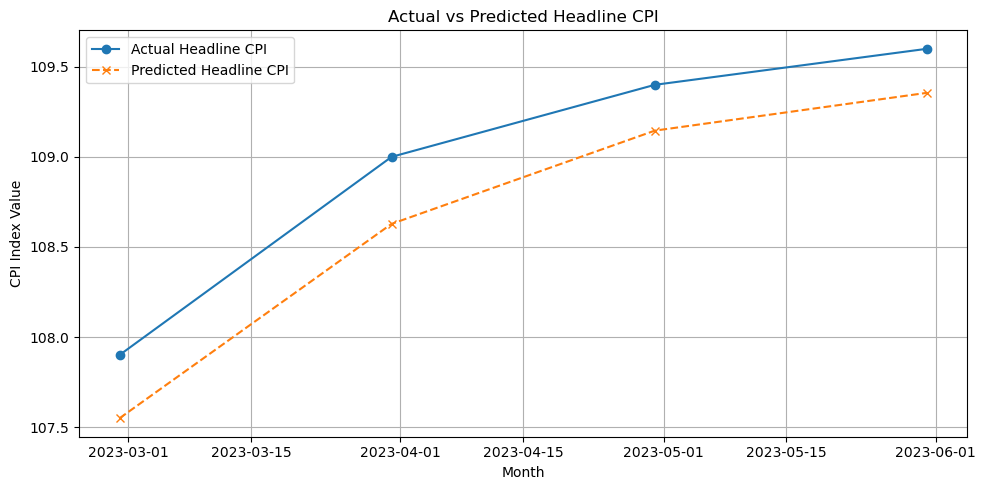

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    y_test.index,
    y_test.values,
    marker='o',
    label='Actual Headline CPI'
)

plt.plot(
    y_test.index,
    y_pred,
    marker='x',
    linestyle='--',
    label='Predicted Headline CPI'
)

plt.title('Actual vs Predicted Headline CPI')
plt.xlabel('Month')
plt.ylabel('CPI Index Value')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [82]:
X_latest = X.iloc[-1:]   # last available month
july_headline_cpi = model.predict(X_latest)[0]

july_headline_cpi

np.float64(109.3554904663337)

In [84]:
from sklearn.linear_model import Ridge

predictions = {}

for category in df_pivot.columns:
    # 1. Define features and target for this category
    X_cat = df_features.drop(columns=[category])
    y_cat = df_features[category]

    # 2. Train model
    model_cat = Ridge(alpha=1.0)
    model_cat.fit(X_cat, y_cat)

    # 3. Predict July using LAST ROW (correct + safe)
    X_july = X_cat.iloc[-1:]
    predictions[category] = model_cat.predict(X_july)[0]


In [86]:
import pandas as pd

pred_df = pd.DataFrame(
    predictions.items(),
    columns=['Category', 'Predicted_Value']
)

pred_df = pred_df.sort_values(
    by='Predicted_Value',
    ascending=True
).reset_index(drop=True)

pred_df

,Category,Predicted_Value
0,Communication,99.748446
1,Clothing and footwear,104.071405
2,Housing and utilities,104.584341
3,Recreation and culture,104.760151
4,Household contents and services,107.579099
5,Miscellaneous goods and services,109.461897
6,Headline CPI,109.620806
7,Restaurants and hotels,110.243339
8,Health,110.300800
9,Education,110.484252


In [87]:
pred_df.head()   # smallest values
pred_df.tail()   #

,Category,Predicted_Value
8,Health,110.300800
9,Education,110.484252
10,Alcoholic beverages and tobacco,110.682989
11,Transport,113.461372
12,Food and non-alcoholic beverages,117.852856


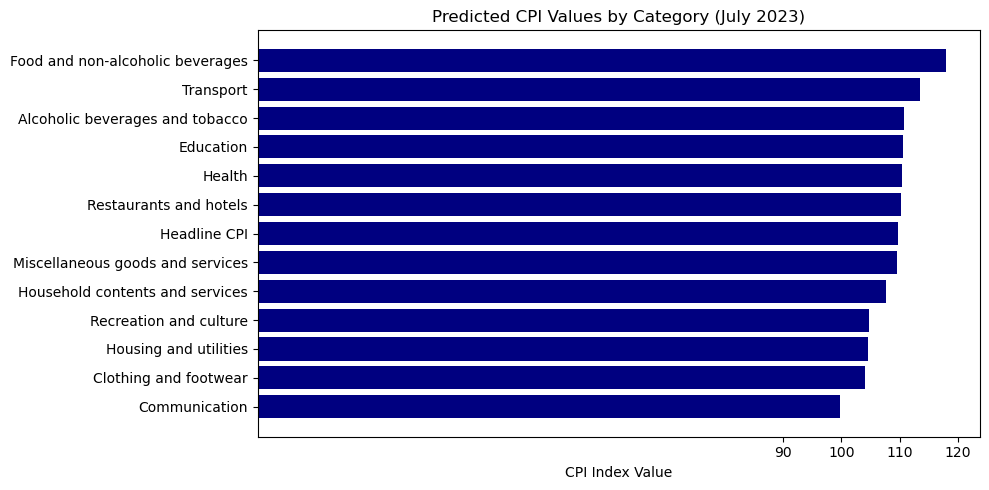

In [110]:
# Sort highest to lowest
pred_df_sorted = pred_df.sort_values(
    by='Predicted_Value',
    ascending=False
)

plt.figure(figsize=(10, 5))

bars = plt.barh(
    pred_df_sorted['Category'],
    pred_df_sorted['Predicted_Value'],
    color='navy'
)

plt.xlabel('CPI Index Value')
plt.title('Predicted CPI Values by Category (July 2023)')

# Invert y-axis so highest value appears at the top
plt.gca().invert_yaxis()

# Set x-axis ticks at intervals of 10
xmin = int(pred_df_sorted['Predicted_Value'].min() // 10 * 10)
xmax = int(pred_df_sorted['Predicted_Value'].max() // 10 * 10 + 10)
plt.xticks(np.arange(xmin, xmax + 1, 10))


plt.tight_layout()
plt.show()
plt.show()


### Headline CPI Trend (Core Inflation Story)

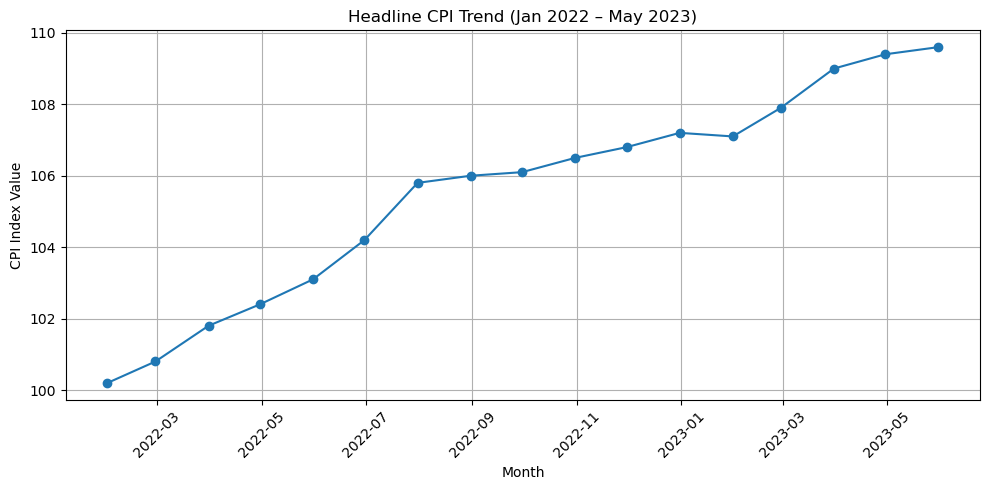

In [93]:
plt.figure(figsize=(10, 5))
plt.plot(df_pivot.index, df_pivot['Headline CPI'], marker='o')

plt.title('Headline CPI Trend (Jan 2022 – May 2023)')
plt.xlabel('Month')
plt.ylabel('CPI Index Value')

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Key CPI Categories Driving Inflation

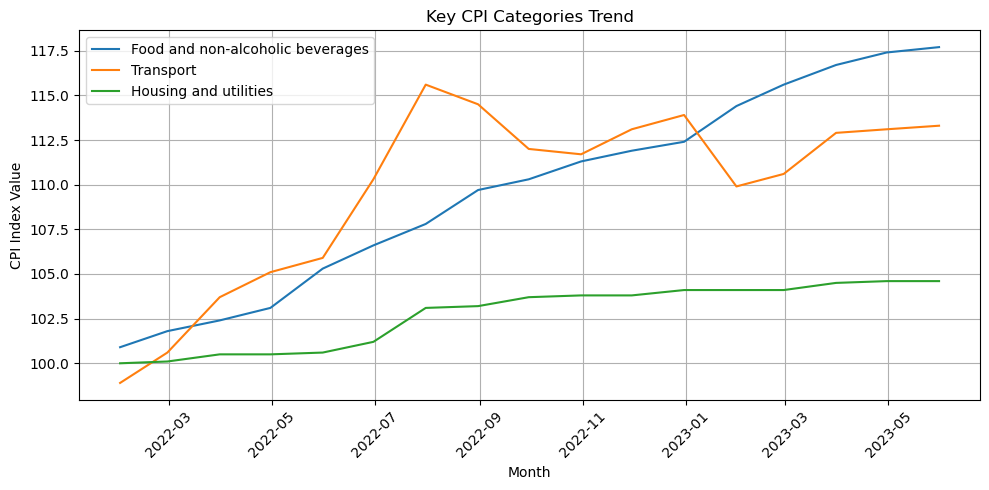

In [89]:
plt.figure(figsize=(10, 5))

key_categories = [
    'Food and non-alcoholic beverages',
    'Transport',
    'Housing and utilities'
]

for category in key_categories:
    plt.plot(df_pivot.index, df_pivot[category], label=category)

plt.title('Key CPI Categories Trend')
plt.xlabel('Month')
plt.ylabel('CPI Index Value')

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Month‑on‑Month Percentage Change Heatmap

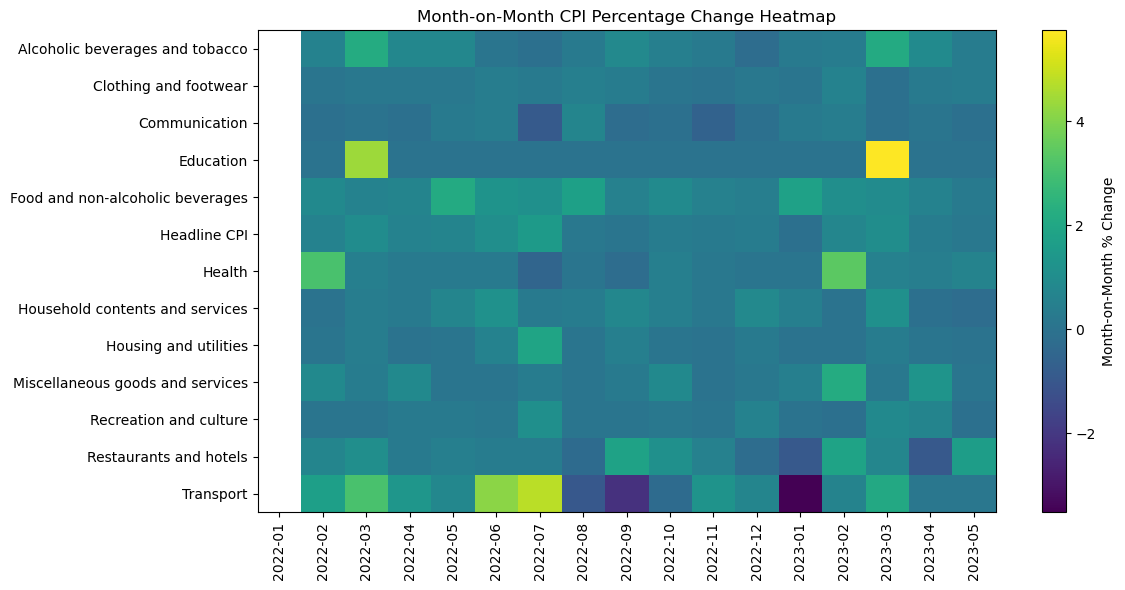

In [90]:
import numpy as np

# Calculate month-on-month percentage change
df_pct_change = df_pivot.pct_change() * 100

plt.figure(figsize=(12, 6))
plt.imshow(df_pct_change.T, aspect='auto')

plt.colorbar(label='Month-on-Month % Change')

plt.yticks(
    range(len(df_pct_change.columns)),
    df_pct_change.columns
)

plt.xticks(
    range(len(df_pct_change.index)),
    [d.strftime('%Y-%m') for d in df_pct_change.index],
    rotation=90
)

plt.title('Month-on-Month CPI Percentage Change Heatmap')
plt.tight_layout()
plt.show()

In [99]:
# Compare naive baseline vs model
naive_pred = y_test.shift(1).dropna()
aligned_actual = y_test.loc[naive_pred.index]

from sklearn.metrics import mean_absolute_error

print("Naive MAE:", mean_absolute_error(aligned_actual, naive_pred))
print("Model MAE:", mean_absolute_error(y_test, y_pred))

Naive MAE: 0.5666666666666629
Model MAE: 0.3054652377471214
